# Wine Quality

## importy + dane

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import datetime as dttm
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV
from IPython.display import display
pd.set_option('display.max_colwidth', None)

data = load_wine(as_frame=True)
df = pd.DataFrame(data.data)
display(df.shape)
display(df.columns)

df = df.assign(quality = data.target, good = (data.target == 2))
train_data, test_data = train_test_split(df, test_size=0.2, random_state=67, stratify=df['quality'])
train_data = pd.DataFrame(train_data); test_data = pd.DataFrame(test_data)

(178, 13)

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='str')

## skalowanie + wstępna analiza

In [9]:
scaler = StandardScaler()
scaler.fit(train_data.drop(columns=['quality', 'good']))
train_scaled = pd.DataFrame(
    scaler.transform(train_data.drop(columns=['quality', 'good'])),
    columns=train_data.drop(columns=['quality', 'good']).columns,
    index=train_data.index
)
train_scaled['quality'] = train_data['quality']; train_scaled['good'] = train_data['good']

test_scaled = pd.DataFrame(
    scaler.transform(test_data.drop(columns=['quality', 'good'])),
    columns=test_data.drop(columns=['quality', 'good']).columns,
    index=test_data.index
)
test_scaled['quality'] = test_data['quality']; test_scaled['good'] = test_data['good']

average = train_scaled.groupby('quality').mean() # mamy tylko 3 klasy win
display(average) # ciężko coś wyczytać, ale w pewnych kategoriach najlepsze wina mają wyraźnie skrajne wartości w pewnych kategoriach (np. ash, alcanity_of_ash, hue)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,good
quality,,,,,,,,,,,,,,
0,0.937943,-0.294670,0.268332,-0.770250,0.433340,0.857281,0.924089,-0.603829,0.569962,0.232487,0.438515,0.770164,1.173290,0.0
1,-0.852505,-0.349167,-0.427057,0.218201,-0.363647,-0.050931,0.076560,0.041672,0.072516,-0.841557,0.421452,0.233816,-0.725602,0.0
2,0.118670,0.888211,0.308701,0.625377,0.009497,-0.983924,-1.257792,0.684333,-0.813727,0.974786,-1.174552,-1.303296,-0.362772,1.0


## PCA

,principal component 1,principal component 2
0,-2.183408,2.200277
1,-3.937245,0.664083
2,2.290371,0.219362
3,-0.383098,-2.187981
4,2.717207,1.851948
5,-2.760543,1.637129
6,-1.624830,-1.871958
7,-0.547847,-2.281436
8,-2.399876,2.734460
9,1.381756,0.760791


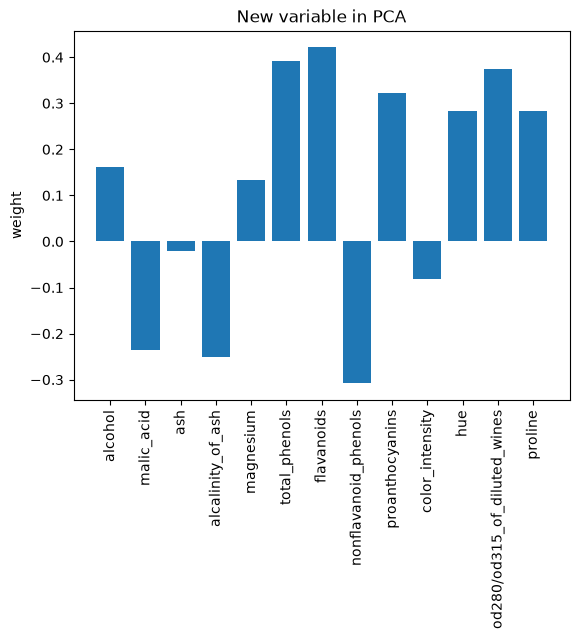

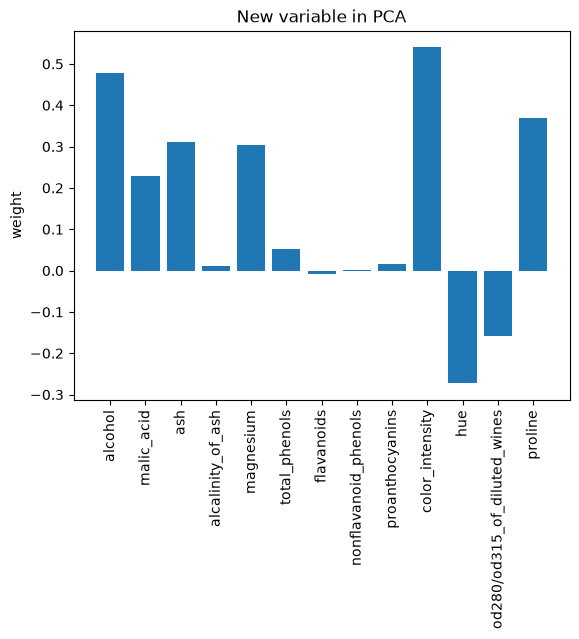

,PC1,PC2
alcohol,0.161087,0.477079
malic_acid,-0.235884,0.228223
ash,-0.020214,0.311681
alcalinity_of_ash,-0.251736,0.010576
magnesium,0.132630,0.304587
total_phenols,0.392637,0.053081
flavanoids,0.421108,-0.008667
nonflavanoid_phenols,-0.308246,0.001833
proanthocyanins,0.321882,0.015829
color_intensity,-0.081947,0.539830


flavanoids                      0.421108
total_phenols                   0.392637
od280/od315_of_diluted_wines    0.374442
proanthocyanins                 0.321882
nonflavanoid_phenols            0.308246
hue                             0.283329
proline                         0.282352
alcalinity_of_ash               0.251736
malic_acid                      0.235884
alcohol                         0.161087
magnesium                       0.132630
color_intensity                 0.081947
ash                             0.020214
Name: PC1, dtype: float64

color_intensity                 0.539830
alcohol                         0.477079
proline                         0.369363
ash                             0.311681
magnesium                       0.304587
hue                             0.273110
malic_acid                      0.228223
od280/od315_of_diluted_wines    0.157158
total_phenols                   0.053081
proanthocyanins                 0.015829
alcalinity_of_ash               0.010576
flavanoids                      0.008667
nonflavanoid_phenols            0.001833
Name: PC2, dtype: float64

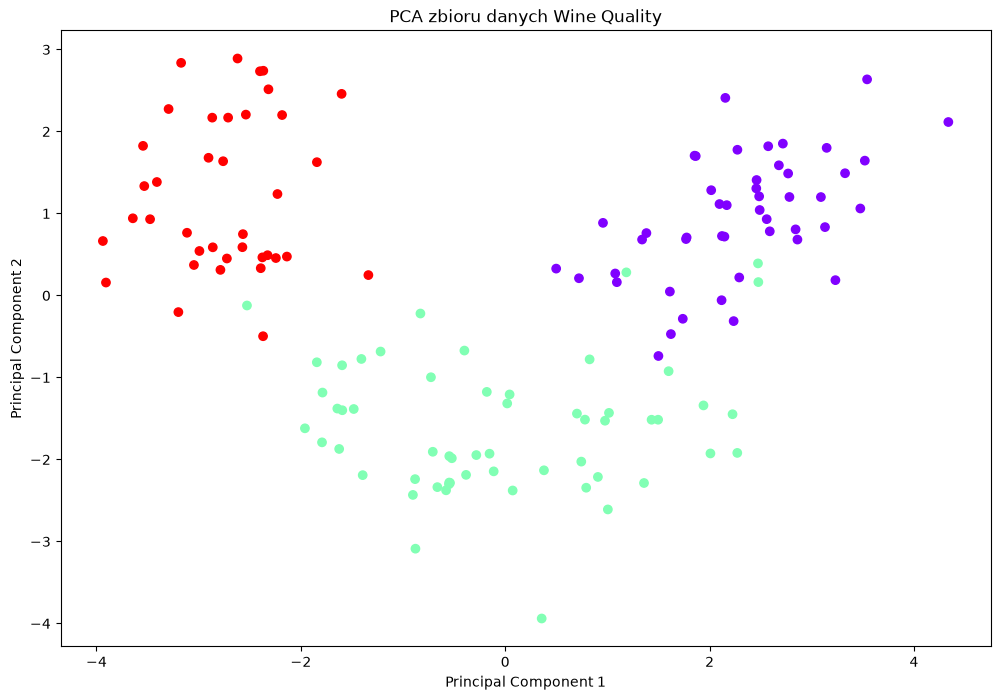

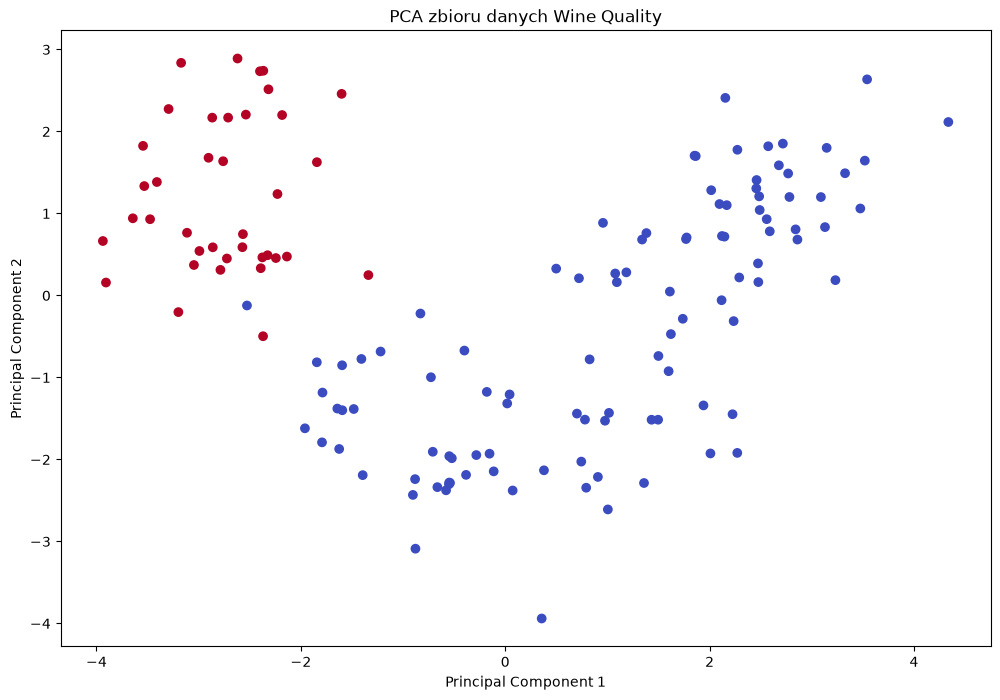

In [10]:
pca = PCA(n_components=2, random_state=67)
wine_pca = pd.DataFrame(data = pca.fit_transform(train_scaled.drop(columns=['quality','good'])), columns=['principal component 1', 'principal component 2'])
display(wine_pca.head(10))

for component in pca.components_:
  plt.bar(train_scaled.drop(columns=['quality','good']).columns, component)
  plt.xticks(rotation=90)
  plt.title('New variable in PCA')
  plt.ylabel('weight')
  plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2'],
    index=train_scaled.drop(columns=['quality','good']).columns
)
display(loadings) # dosyć zbalansowane wagi, prawie każda w przedziale [-0.4, 0.4]
display(loadings["PC1"].abs().sort_values(ascending=False))
display(loadings["PC2"].abs().sort_values(ascending=False))

plt.figure(figsize=(12, 8))
plt.scatter(wine_pca['principal component 1'], wine_pca['principal component 2'], c=train_scaled['quality'], cmap='rainbow')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA zbioru danych Wine Quality')
plt.show() # mało zbite klastry, ale widać wyraźne 3 grupy odpowiadające jakościom, nie ma potrzeby klasteryzować

plt.figure(figsize=(12, 8))
plt.scatter(wine_pca['principal component 1'], wine_pca['principal component 2'], c=train_scaled['good'], cmap='coolwarm')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA zbioru danych Wine Quality')
plt.show() # tak jak powyżej, po prostu 2 kolorki zamiast 3

## Klasyfikacja

Best params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Best CV score: 0.981


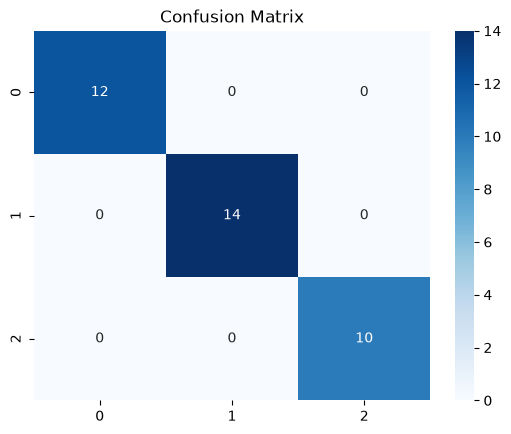

Accuracy: 1.000, Precision: 1.000
Recall: 1.000, F1: 1.000, AUC: 1.000


In [11]:
param_grid = {
    'n_neighbors' : [3,5,7,9,11,13],
    'metric' : ['euclidean','manhattan','minkowski'],
    'weights' : ['uniform','distance']
}
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1_macro'
)
grid_search.fit(train_scaled.drop(columns=['quality','good']), train_scaled['quality'])

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")
# Najlepszy model
best_model = grid_search.best_estimator_

pred = pd.Series(best_model.predict(test_scaled.drop(columns=['quality','good'])))

acc = accuracy_score(test_scaled['quality'], pred)
precision = precision_score(test_scaled['quality'], pred, average='macro')
recall = recall_score(test_scaled['quality'], pred, average='macro')
f1 = f1_score(test_scaled['quality'], pred, average='macro')

cm = confusion_matrix(test_scaled['quality'], pred)
sbn.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title('Confusion Matrix')
plt.show()

proba = best_model.predict_proba(test_scaled.drop(columns=['quality','good']))
auc = roc_auc_score(test_scaled['quality'], proba, multi_class='ovr', average='macro')
print(f"Accuracy: {acc:.3f}, Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")
